In [1]:
import sys
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path.cwd().parent))  # points to src/
from shared_modeling import (
    build_combined_feature_frame,
    run_interpretability_suite,
    run_model_experiment,
)

# Toggle this to keep only the clear-cut breastfeeding classes.
keep_only_clearcut_classes = True
breastfeeding_classes_to_keep = [1, 2]

outcome_df = pd.read_csv('../../Data/V4A.csv', usecols=['PublicID', 'V4AH01'], encoding='latin-1')
outcome_df['V4AH01'] = outcome_df['V4AH01'].replace('D', pd.NA)
outcome_df['V4AH01'] = pd.to_numeric(outcome_df['V4AH01'], errors='coerce')
outcome_df = outcome_df.drop_duplicates(subset=['PublicID'])
outcome_df_to_show = outcome_df[outcome_df['V4AH01'].isin(breastfeeding_classes_to_keep)] if keep_only_clearcut_classes else outcome_df
outcome_df_to_show['V4AH01'].value_counts() # 1 - breast feed only, 2 - bottle feed only, 3 - both

/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


V4AH01
1.0    3042
2.0     621
Name: count, dtype: int64

In [12]:
combined_inputs = build_combined_feature_frame(
    data_dir=Path('../../Data'),
    outcome_path='V4A.csv',
    outcome_column='V4AH01',
    outcome_encoding='latin-1',
    outcome_replace_map={'D': pd.NA},
    include_paternal=False,
    include_drugs=False,
    include_food=False,
    include_health_knowledge=False,
    include_mother_demo=False,
    include_physical_activity=False,
    include_sleep=False,
)
feature_lists = combined_inputs['feature_lists']
numeric_features = feature_lists['numeric_features']
categorical_features = feature_lists['categorical_features']
ordinal_features = feature_lists['ordinal_features']
binary_features = feature_lists['binary_features']
feature_columns = feature_lists['feature_columns']
combined_df = combined_inputs['combined_df']
outcome_df = combined_inputs['outcome_df']

if keep_only_clearcut_classes:
    combined_df = combined_df[combined_df['V4AH01'].isin(breastfeeding_classes_to_keep)].copy()
    outcome_df = outcome_df[outcome_df['V4AH01'].isin(breastfeeding_classes_to_keep)].copy()

split_frame = outcome_df[['PublicID', 'V4AH01']].dropna().drop_duplicates(subset=['PublicID'])
train_ids, test_ids = train_test_split(
    split_frame['PublicID'],
    test_size=0.2,
    random_state=42,
    stratify=split_frame['V4AH01'],
)

X = combined_df[feature_columns]
y = combined_df['V4AH01']
train_df = combined_df[combined_df['PublicID'].isin(train_ids)].copy()
test_df = combined_df[combined_df['PublicID'].isin(test_ids)].copy()
X_train = train_df.drop(['V4AH01', 'PublicID'], axis=1)
X_test = test_df.drop(['V4AH01', 'PublicID'], axis=1)
y_train = train_df['V4AH01']
y_test = test_df['V4AH01']
combined_df


,PublicID,oDM,ChronHTN,acog_PEgHTN,ResilienceTotalScore,ResilienceLevel,stress_average,FrequencyOfHassles,FrequencyOfUplifts,IntensityOfHassles,IntensityOfUplifts,HassleUpliftFrequencyRatio,HassleUpliftIntensityRatio,StressTotalScore,StressLevel,V4AH01
1,00007I,3.0,2.0,7.0,106.0,1.0,1.538462,10.0,10.0,2.0,2.6,1.0,0.769231,18.0,0.5,2.0
4,00017F,3.0,2.0,7.0,100.0,2.0,1.538462,10.0,10.0,1.9,2.7,1.0,0.703704,18.0,0.5,1.0
7,00023K,3.0,2.0,7.0,95.0,2.0,1.538462,10.0,10.0,1.5,2.6,1.0,0.576923,25.0,0.5,1.0
8,00027C,3.0,2.0,7.0,120.0,1.0,1.076923,10.0,10.0,1.0,4.0,1.0,0.250000,15.0,0.5,2.0
9,00030N,3.0,2.0,7.0,112.0,1.0,1.384615,10.0,10.0,1.5,1.0,1.0,1.500000,12.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6654,17335T,3.0,2.0,7.0,113.0,1.0,1.615385,10.0,10.0,1.7,3.1,1.0,0.548387,17.0,0.5,1.0
6655,17339L,3.0,2.0,7.0,122.0,1.0,1.923077,10.0,10.0,1.6,3.8,1.0,0.421053,8.0,0.0,1.0
6656,17340D,3.0,2.0,7.0,102.0,1.0,1.384615,10.0,10.0,1.6,3.9,1.0,0.410256,25.0,0.5,1.0
6657,17343U,3.0,2.0,7.0,96.0,2.0,1.666667,10.0,10.0,2.0,3.0,1.0,0.666667,13.0,0.0,1.0


In [13]:
# LR block using maternal health
lr_model, lr_pred, lr_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'lr',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)

Dropping rows with missing values because impute=False (train: 430, test: 99).
Final dataset sizes for LR (impute=False): train=2500, test=634
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model

Best parameters found: {'classifier__C': 100, 'classifier__l1_ratio': 0.0}
Best CV Score (f1): 0.7726
Model Coefficients:
num__ResilienceTotalScore: 0.02078097595794753
num__stress_average: -0.21664256839632354
num__FrequencyOfHassles: -0.060824887355675136
num__FrequencyOfUplifts: 0.17677749354505412
num__IntensityOfHassles: -0.42652711405531485
num__IntensityOfUplifts: 0.3030717372401837
num__HassleUpliftFrequencyRatio: -0.04669209389367253
num__HassleUpliftIntensityRatio: 0.5030381887772739
num__StressTotalScore: 0.7267647110100557
bin__ChronHTN: -2.0242265111170297
bin__ResilienceLevel: 0.022849126022230704
bin__StressLevel: -1.1192528652078488
cat__oDM_1.0: 0.36403347065578473
cat__oDM_2.0: 1.240313565713256
cat__oDM_3.0: 1.279663837322743
cat__acog_PEgHTN_1.0: 2.8461306200597902
cat__acog_PEgHTN_2.0: -1.2066737079343142
cat__acog_PEgHTN_3.0: 0.34150333334281346
cat__acog_PEgHTN_4.0: 0.36510213068352837
cat__acog_PEgHTN_5.0: 0.32864378926359455
cat__acog_PEgHTN_6.0: 0.223923832463

In [15]:
# RF block using maternal health
rf_model, rf_pred, rf_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'rf',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)

Dropping rows with missing values because impute=False (train: 430, test: 99).
Final dataset sizes for RF (impute=False): train=2500, test=634
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'classifier__max_depth': 18, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 3, 'classifier__n_estimators': 500}
Best CV Score (f1): 0.8902
Feature Importances:
num__ResilienceTotalScore: 0.13062490086423445
num__stress_average: 0.11540374628462252
num__FrequencyOfHassles: 0.002339531056690435
num__FrequencyOfUplifts: 0.00141428293566409
num__IntensityOfHassles: 0.12349204274615555
num__IntensityOfUplifts: 0.11651429102907285
num__HassleUpliftFrequencyRatio: 0.004032404079056349
num__HassleUpliftIntensityRatio: 0.1235549563675377
num__StressTotalScore: 0.1703160313245462
bin__ChronHTN: 0.026743393802465962
bin__ResilienceLevel: 0.02774778290564119
bin__StressLevel: 0.04714629663896582
cat__oDM_1.0: 0.0032312624739438585
cat__oDM_2.0: 0.00788

In [14]:
# XGBoost block using maternal health
xgb_model, xgb_pred, xgb_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'xgb',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)

Dropping rows with missing values because impute=False (train: 430, test: 99).
Final dataset sizes for XGB (impute=False): train=2500, test=634
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters found: {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 4, 'classifier__n_estimators': 100, 'classifier__subsample': 0.7}
Best CV Score (f1): 0.3441
Feature Importances:
num__ResilienceTotalScore: 0.036664098501205444
num__stress_average: 0.07818830758333206
num__FrequencyOfHassles: 0.05070573836565018
num__FrequencyOfUplifts: 0.0
num__IntensityOfHassles: 0.07365546375513077
num__IntensityOfUplifts: 0.043941449373960495
num__HassleUpliftFrequencyRatio: 0.0
num__HassleUpliftIntensityRatio: 0.05776384100317955
num__StressTotalScore: 0.1257786601781845
bin__ChronHTN: 0.08267976343631744
bin__ResilienceLevel: 0.03846851363778114
bin__StressLevel: 0.12300736457109451
cat__oDM_1.0: 0.007746861316263676
cat__oDM_2.0: 0.0
cat

In [16]:
# SVM block using maternal health
svm_model, svm_pred, svm_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'svm',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)

Dropping rows with missing values because impute=False (train: 430, test: 99).
Final dataset sizes for SVM (impute=False): train=2500, test=634
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found: {'classifier__estimator__C': 100, 'classifier__estimator__gamma': 0.1, 'classifier__estimator__kernel': 'rbf'}
Best CV Score (f1): 0.8274
Skipping feature-level SVM output: non-linear SVM has no coefficients.
Evaluation Metrics for SVM with shared preprocessing and adaptive CV scoring:
Accuracy: 0.7208
Precision (positive class): 0.2000
Recall (positive class): 0.2812
F1 (positive class): 0.2338
Macro Precision: 0.5309
Macro Recall: 0.5403
Macro F1: 0.5315
ROC AUC: 0.5279


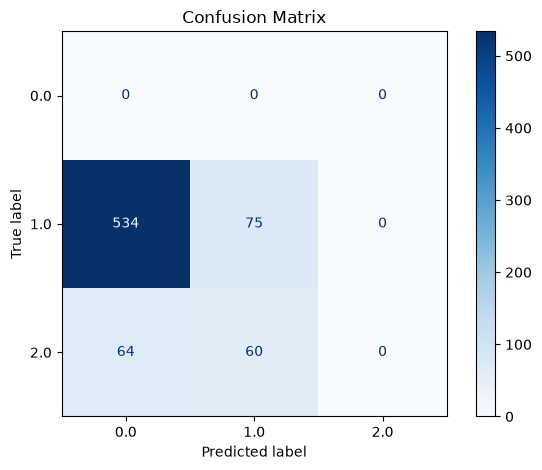

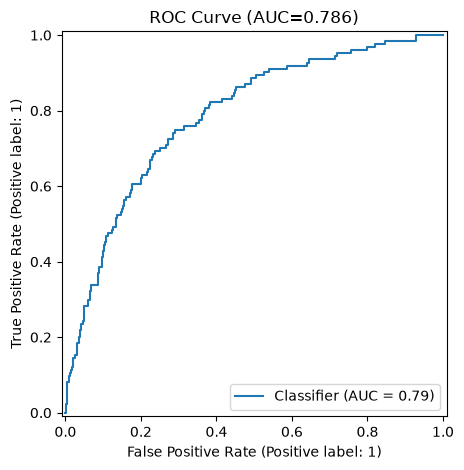

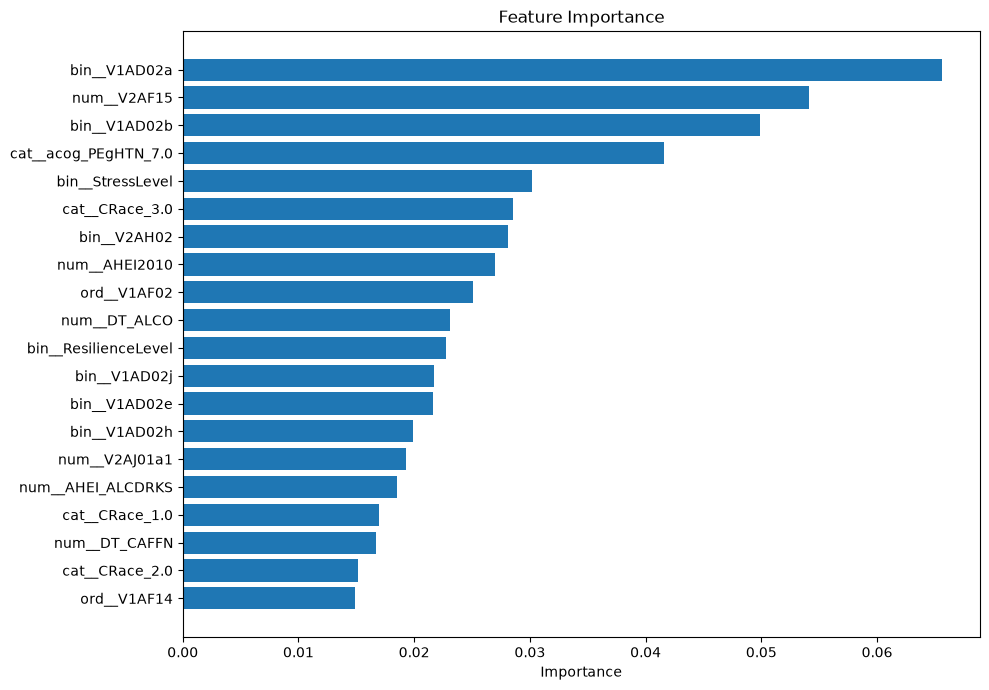

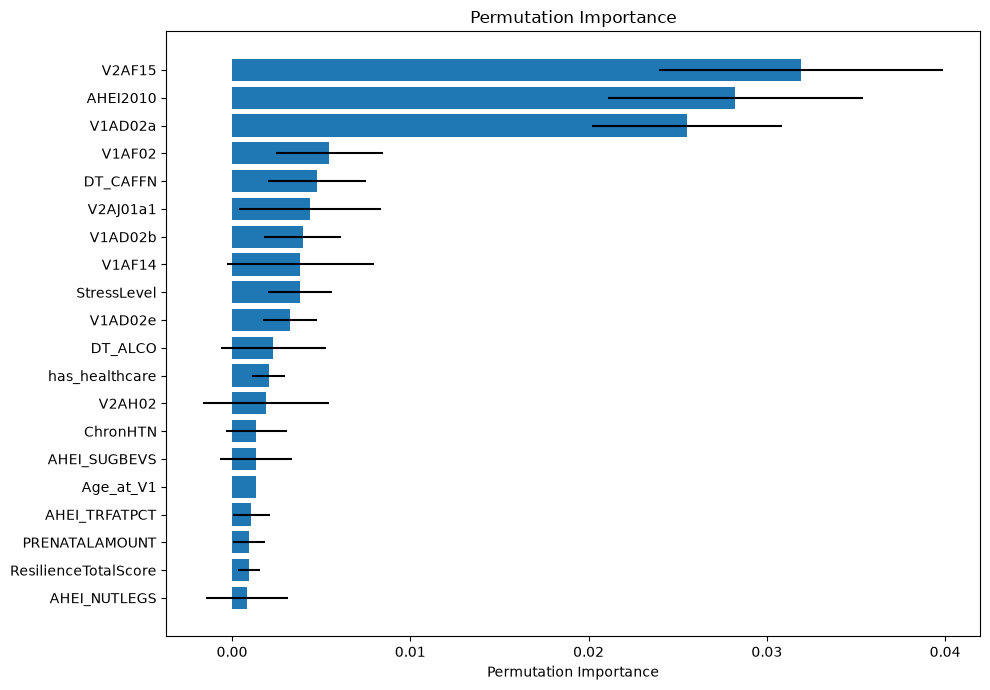

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP skipped: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.


In [11]:
# Interpretability for the XGBoost breastfeeding model.
# Swap xgb_model for lr_model, rf_model, or svm_model if you want a different view.
run_interpretability_suite(xgb_model, X_train, X_test, y_test, labels=breastfeeding_classes_to_keep if keep_only_clearcut_classes else [1, 2, 3], top_n=20)